# Dataset Preprocessing - Visualizations and Plots

In [15]:
import numpy as np
import warnings
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import mne 
import pyvista
import vtk
from mne.io import concatenate_raws, read_raw_edf
from mne.datasets import eegbci
from mne.preprocessing import ICA
from torch.utils.data import Dataset

%matplotlib notebook 
# for interactive plotting (may be deleted later)
# prefiguration of plot size
matplotlib.rcParams['figure.figsize'] = (5, 5)

## Dataset Description
### Experimental Procedure
Subjects (n=109) were asked to complete 14 experimental runs. The first two recordings were one-minute baseline recordings, with one in which the subjects had their eyes open, and closed in the other. Out of the twelve other runs, participants had to execute four two-minute task conditions three times. In the case of the unilateral fist tasks, subjects saw a visual target appearing on the left or right side of a screen and then had to either open or close their corresponding fist, or imagine doing so until the target disappeared. Another task was the bilateral hand or foot tasks where the visual targets appeared at the top or bottom of the screen, indicating subjects to either open or close both their fists (visual target displayed at top) or feet, or alternatively again just imagine the movement.

Schalk's 2009 dataset from PhysioNet is very useful since it allows for exploring differences between imagined and actual movement neural encoding, while exploring lateralization and somatotopy. Furthermore, it has been widely used and proofen to be well documented and suitable for BCI experimentation.

### Data Format
Each recording has 64 EEG signals sampled at 160 samples/s along with an annotation channel. Event annotations have also been provided by the original researchers. Annotations codes are:
* T0 for rest
* T1 for the onset of left-fist movement/imagery in unilateral fist runs and both-fists movement/imagery in bilateral hand/foot runs
* T2 for the onset of right-fist movement/imagery in the unilateral condition and both-feet movement/imagery in the bilateral condition

=> since the annotations have different meanings dependent on the condition, runs have to be classified using the run number
=> "[s]ignal indices in the recordings are numbered from 0 to 63, while the associated montage figure numbers electrodes from 1 to 64

### Reference
_Schalk, G. (2009). EEG Motor Movement/Imagery Dataset (version 1.0.0). PhysioNet. RRID:SCR_007345. https://doi.org/10.13026/C28G6P, original publication: Schalk, G., McFarland, D.J., Hinterberger, T., Birbaumer, N., Wolpaw, J.R. BCI2000: A General-Purpose Brain-Computer Interface (BCI) System. IEEE Transactions on Biomedical Engineering 51(6):1034-1043, 2004._

In [16]:
# Download files and return paths
subject_id = [1]
runs = [4, 8, 12]
"""Subject range has been modified to 3/80 subjects for plotting purpose"""
paths = [eegbci.load_data(subject_id, runs) for subject_id in range(1,3)]
paths = np.concatenate(paths)


In [17]:
# Load the files
raws = [read_raw_edf(path, preload=True, stim_channel='auto', verbose='WARNING') 
        for path in paths]

In [18]:
# Concatenate runs from subject(s)
raw = concatenate_raws(raws)
print(raw) # Overview
print(raw.info)

# Standardize  because different electrodes might have varying amplitudes 
# due to differences in recording conditions or electrode impedance
eegbci.standardize(raw)

<RawEDF | S001R04.edf, 64 x 119040 (744.0 s), ~58.2 MiB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 17.067 (s)
Plotting power spectral density (dB=True).


<IPython.core.display.Javascript object>

/var/folders/yp/dxtsktqs0q19r5m1wr3gpy780000gn/T/ipykernel_7962/3256638536.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd(tmin=0, tmax=60, fmin=2, fmax=60, average=False, spatial_colors=True, xscale='log')


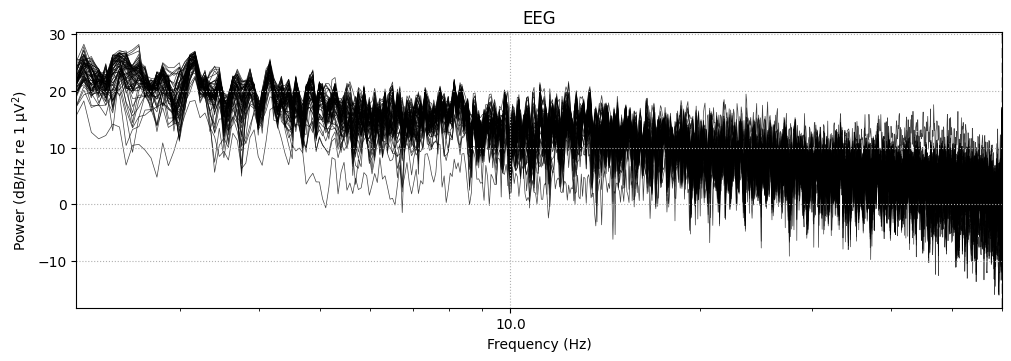

In [19]:
# Downsample data
raw.resample(sfreq=120)
raw.plot_psd(tmin=0, tmax=60, fmin=2, fmax=60, average=False, spatial_colors=True, xscale='log')

In [20]:
# Set montage for spatial analysis later
# Specify positions of electrodes on scalp
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)

<RawEDF | S001R04.edf, 64 x 89280 (744.0 s), ~43.7 MiB, data loaded>

In [27]:
# Plot sensors in 3D
# code does not display currently
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
mne.viz.plot_sensors(raw.info,
                    kind='3d', 
                    ch_type='eeg',
                    show_names=True,
                    sphere='eeg',
                    axes = ax,
                    to_sphere=True,
                    show=True)

ax.set_title('EEG Sensor Placement on Head (Standard 10-20)', fontsize=11, fontweight= 'bold')
ax.set_axis_off()
ax.view_init(elev=20, azim=120)

plt.show()
fig.savefig('sensor_placement.png', dpi=300)

<IPython.core.display.Javascript object>

Effective window size : 17.067 (s)
Plotting power spectral density (dB=True).


<IPython.core.display.Javascript object>

Using matplotlib as 2D backend.


<IPython.core.display.Javascript object>

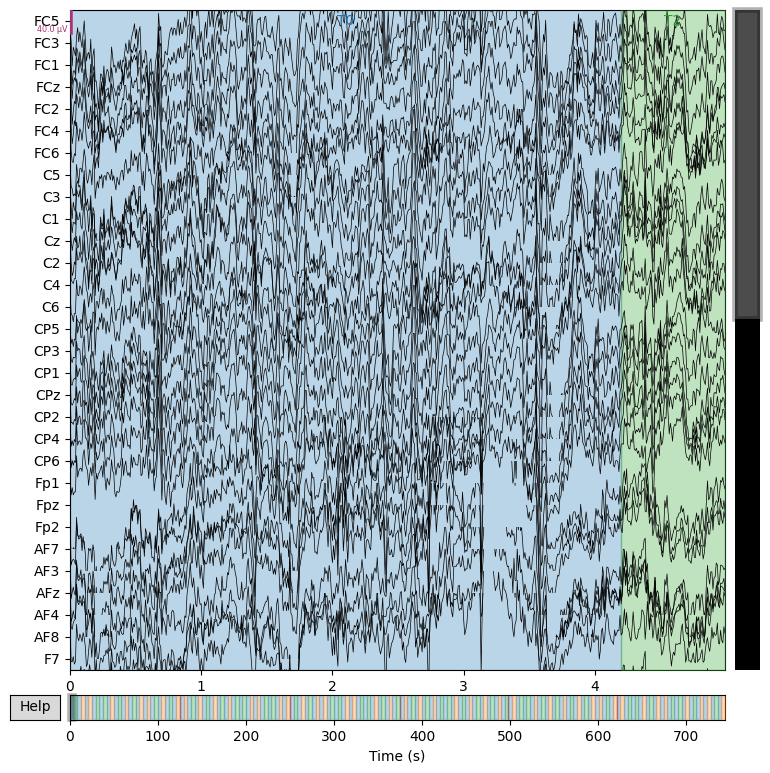

In [23]:
# Power spectral density (PSD) for each sensor type
# Visualize spectral features, freq-by-freq decomposition of signal
raw.compute_psd(fmax=60).plot(picks="data", exclude="bads", amplitude=False)
raw.plot(duration=5, n_channels=30)

In [ ]:
# Filtering
# Remove 60 Hz power line noise using notch filter
raw.notch_filter(60)
# Remove very high and very low frequencies
raw.filter(l_freq=0.5, h_freq=50.0) # only keeping 0.5-50Hz
raw.info['sfreq']

Filtering raw data in 6 contiguous segments
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1057 samples (6.606 s)

Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth

160.0

<IPython.core.display.Javascript object>

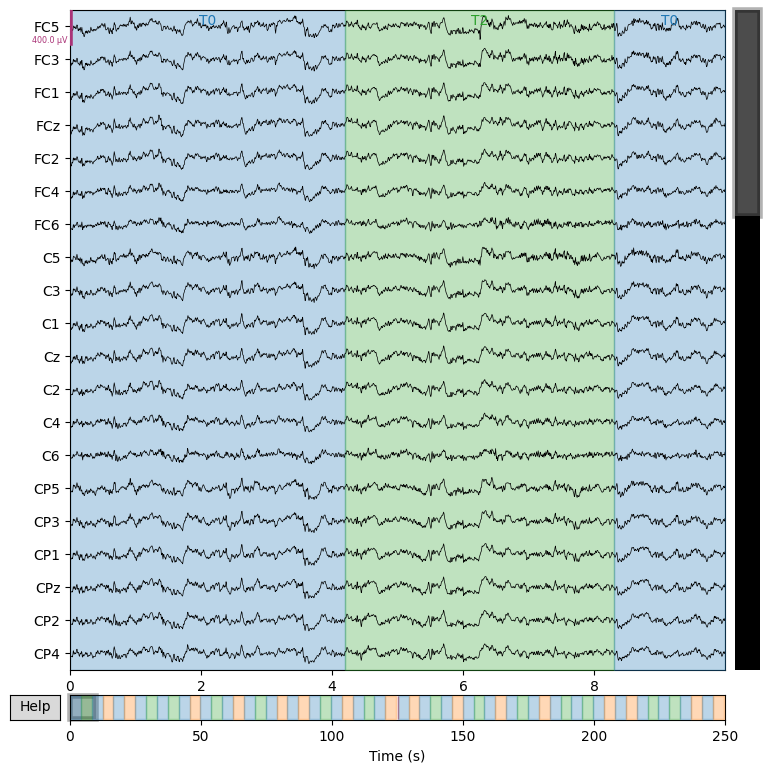

In [ ]:
# Spherical spline interpolation to estimate the location of activity
raw.interpolate_bads(reset_bads=True)
raw.plot(scalings=dict(eeg=200e-6))

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 1.0s.


<IPython.core.display.Javascript object>

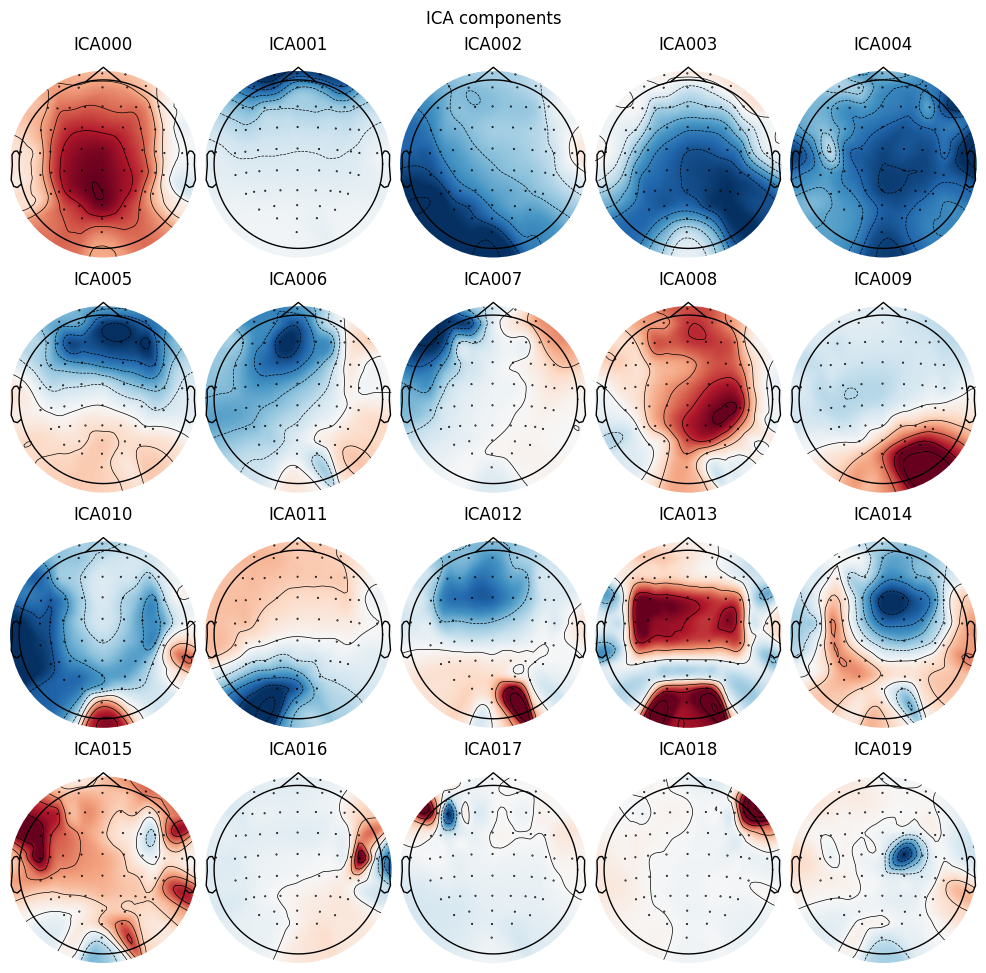

In [ ]:
# Set up and fit Independent component analysis (ICA)
# play around with num_components to get the ones that represent actual brain activity
num_components = 20
ica = ICA(n_components=num_components, random_state=97, max_iter=800)
ica.fit(raw)
# Plot ICA on scalp
ica.plot_components()
# Visualize each component's properties to reject artifactual comp
raw.plot(n_channels=32, scalings=dict(eeg=100e-6))
# Heuristic: looking at spectrum of each component
ica.plot_properties(raw, picks=0) # Exact comp num will prolly not work
ica.plot_properties(raw, picks=9) # Outliers might have increasing intensity for higher freq
# Look at data with bad component removed
ica.plot_overlay(raw, exclude=[0])
ica.exclude = [0]
ica.apply(raw)
raw.plot(scalings=dict(eeg=200e-6))

In [ ]:
# Detecting experimental events
events, _ = mne.events_from_annotations(raw)
# Select only EEG channels from physionet dataset
eeg_channel_inds = mne.pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False, exclude='bads')

# Each annotation has one of three codes:
# T0 = 1 corresponding to rest
# T1 = 2 corresponding to the onset of (real/imagined) movement
# of the left fists (for runs 3, 4, 7, 8, 11 and 12)
# or both fists (for runs 5, 6, 9, 10, 13 and 14)
# T2 = 3 corresponding to motion onset (r/i) of
# the right fist (runs 3, 4, 7, 8, 11 and 12)
# both feet (runs 5, 6, 9, 10, 13 and 14)

<IPython.core.display.Javascript object>

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
124 matching events found
No baseline correction applied
0 projection items activated


<IPython.core.display.Javascript object>

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
124 matching events found
No baseline correction applied
0 projection items activated


[<Figure size 700x600 with 6 Axes>]

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components


<IPython.core.display.Javascript object>

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components


<IPython.core.display.Javascript object>

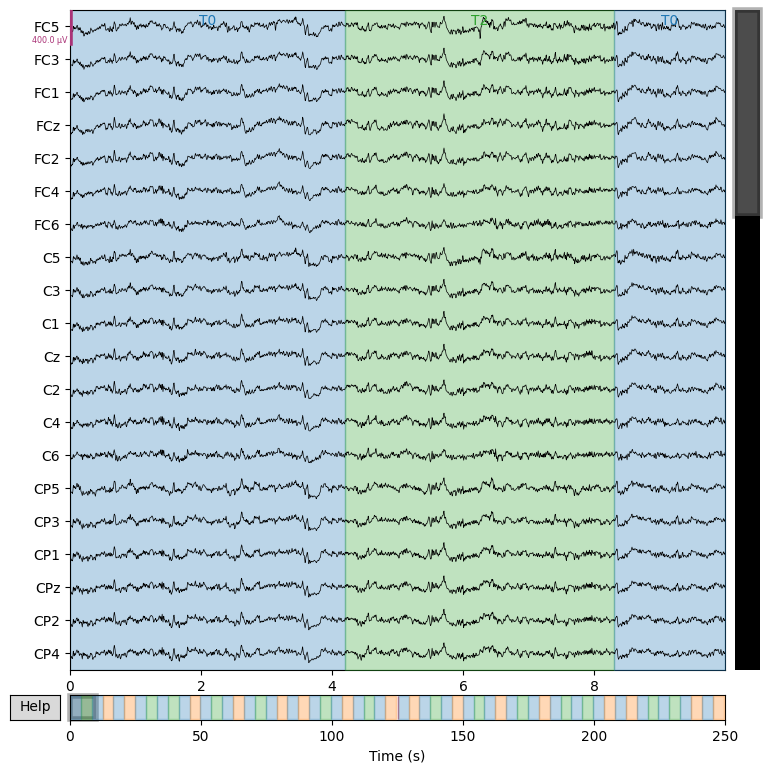

In [ ]:
# Epoching data aka extracting trials
epoched = mne.Epochs(raw, events, dict(left=2, right=3), tmin=1, tmax=4.1, proj=False, picks=eeg_channel_inds,
                     baseline=None, preload=True)